In [1]:
!pip install pandas numpy matplotlib seaborn scipy plotly wordcloud nltk
!pip install torch --index-url https://download.pytorch.org/whl/cpu
!pip install transformers sentence-transformers bertopic umap-learn hdbscan


Looking in indexes: https://download.pytorch.org/whl/cpu


   ---------------------------------------- 0.0/588.9 kB ? eta -:--:--
   ---------------------------------------- 588.9/588.9 kB 7.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 11.9 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# ── Load your cleaned file ──────────────────────────────────────────
# Change the path below to wherever your file is saved on your computer
df = pd.read_csv('WWL_LOS_Survey_Cleaned.csv', dtype=str)

# ── Convert all Likert clean columns to numbers ─────────────────────
likert_clean_cols = [
    'C1_clean','C2_clean','C3_clean','C4_clean',
    'C5_clean','C6_clean','C7_clean','C8_clean',
    'E1_clean','E2_clean',
    'G1_clean','G2_clean','G3_clean','G4_clean',
    'H1_clean','H2_clean','H3_clean',
    'I1_clean','I2_clean','I3_clean',
    'J1_clean','J2_clean','J3_clean','J4_clean'
]

for col in likert_clean_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"✅ Loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"✅ Likert columns converted to numeric")

✅ Loaded successfully: 1482 rows, 73 columns
✅ Likert columns converted to numeric


In [5]:
# ── Descriptive statistics for all Likert clean columns ─────────────
desc = df[likert_clean_cols].describe().T
desc['median'] = df[likert_clean_cols].median()
desc = desc[['count','mean','median','std','min','max']].round(2)

print("=== DESCRIPTIVE STATISTICS — ALL LIKERT QUESTIONS ===")
print(desc)

=== DESCRIPTIVE STATISTICS — ALL LIKERT QUESTIONS ===
          count  mean  median   std  min  max
C1_clean  239.0  2.87     3.0  1.41  1.0  5.0
C2_clean  249.0  2.99     3.0  1.37  1.0  5.0
C3_clean  243.0  2.98     3.0  1.35  1.0  5.0
C4_clean  233.0  3.06     3.0  1.39  1.0  5.0
C5_clean  255.0  3.20     3.0  1.46  1.0  5.0
C6_clean  241.0  3.01     3.0  1.39  1.0  5.0
C7_clean  243.0  2.95     3.0  1.44  1.0  5.0
C8_clean  232.0  3.05     3.0  1.41  1.0  5.0
E1_clean  313.0  3.09     3.0  1.41  1.0  5.0
E2_clean  306.0  2.85     3.0  1.39  1.0  5.0
G1_clean  519.0  3.03     3.0  1.38  1.0  5.0
G2_clean  503.0  3.10     3.0  1.42  1.0  5.0
G3_clean  520.0  3.01     3.0  1.43  1.0  5.0
G4_clean  530.0  2.94     3.0  1.39  1.0  5.0
H1_clean  914.0  3.10     3.0  1.41  1.0  5.0
H2_clean  942.0  3.03     3.0  1.42  1.0  5.0
H3_clean  914.0  3.03     3.0  1.41  1.0  5.0
I1_clean  527.0  2.99     3.0  1.41  1.0  5.0
I2_clean  520.0  3.07     3.0  1.44  1.0  5.0
I3_clean  508.0  3.10     

=== AWARENESS LEVEL BREAKDOWN ===
                    Count  Percentage
B1_awareness_clean                   
Aware Never Used      430        29.0
Used Occasionally     308        20.8
Not Aware             284        19.2
Used Regularly        269        18.2
NaN                   191        12.9


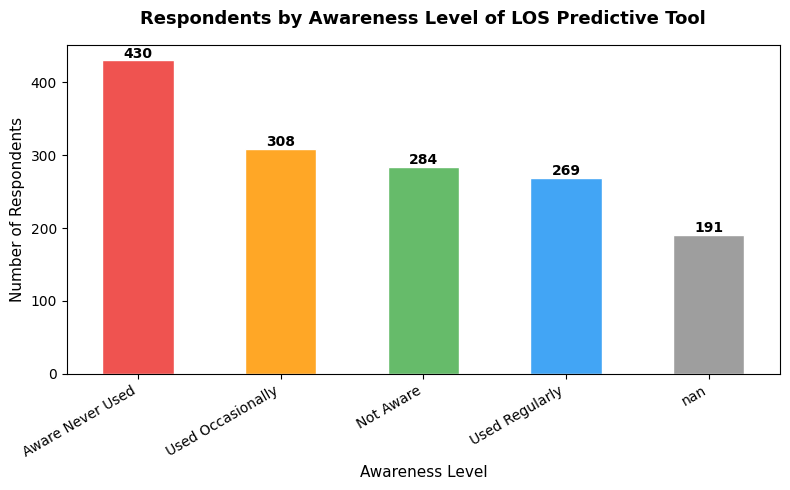

✅ Chart saved as chart_awareness_levels.png


In [7]:
# ── Count and percentage per awareness group ─────────────────────────
awareness_counts = df['B1_awareness_clean'].value_counts(dropna=False)
awareness_pct    = df['B1_awareness_clean'].value_counts(normalize=True, dropna=False) * 100

awareness_summary = pd.DataFrame({
    'Count':      awareness_counts,
    'Percentage': awareness_pct.round(1)
})

print("=== AWARENESS LEVEL BREAKDOWN ===")
print(awareness_summary)

# ── Bar chart ────────────────────────────────────────────────────────
plt.figure(figsize=(8,5))
colors = ['#EF5350','#FFA726','#66BB6A','#42A5F5','#9E9E9E']

awareness_counts.dropna().plot(
    kind='bar',
    color=colors[:len(awareness_counts.dropna())],
    edgecolor='white',
    figsize=(8,5)
)

plt.title('Respondents by Awareness Level of LOS Predictive Tool',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Awareness Level', fontsize=11)
plt.ylabel('Number of Respondents', fontsize=11)
plt.xticks(rotation=30, ha='right')

# Add count labels on top of each bar
ax = plt.gca()
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 4,
        str(int(bar.get_height())),
        ha='center', fontsize=10, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('chart_awareness_levels.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart_awareness_levels.png")

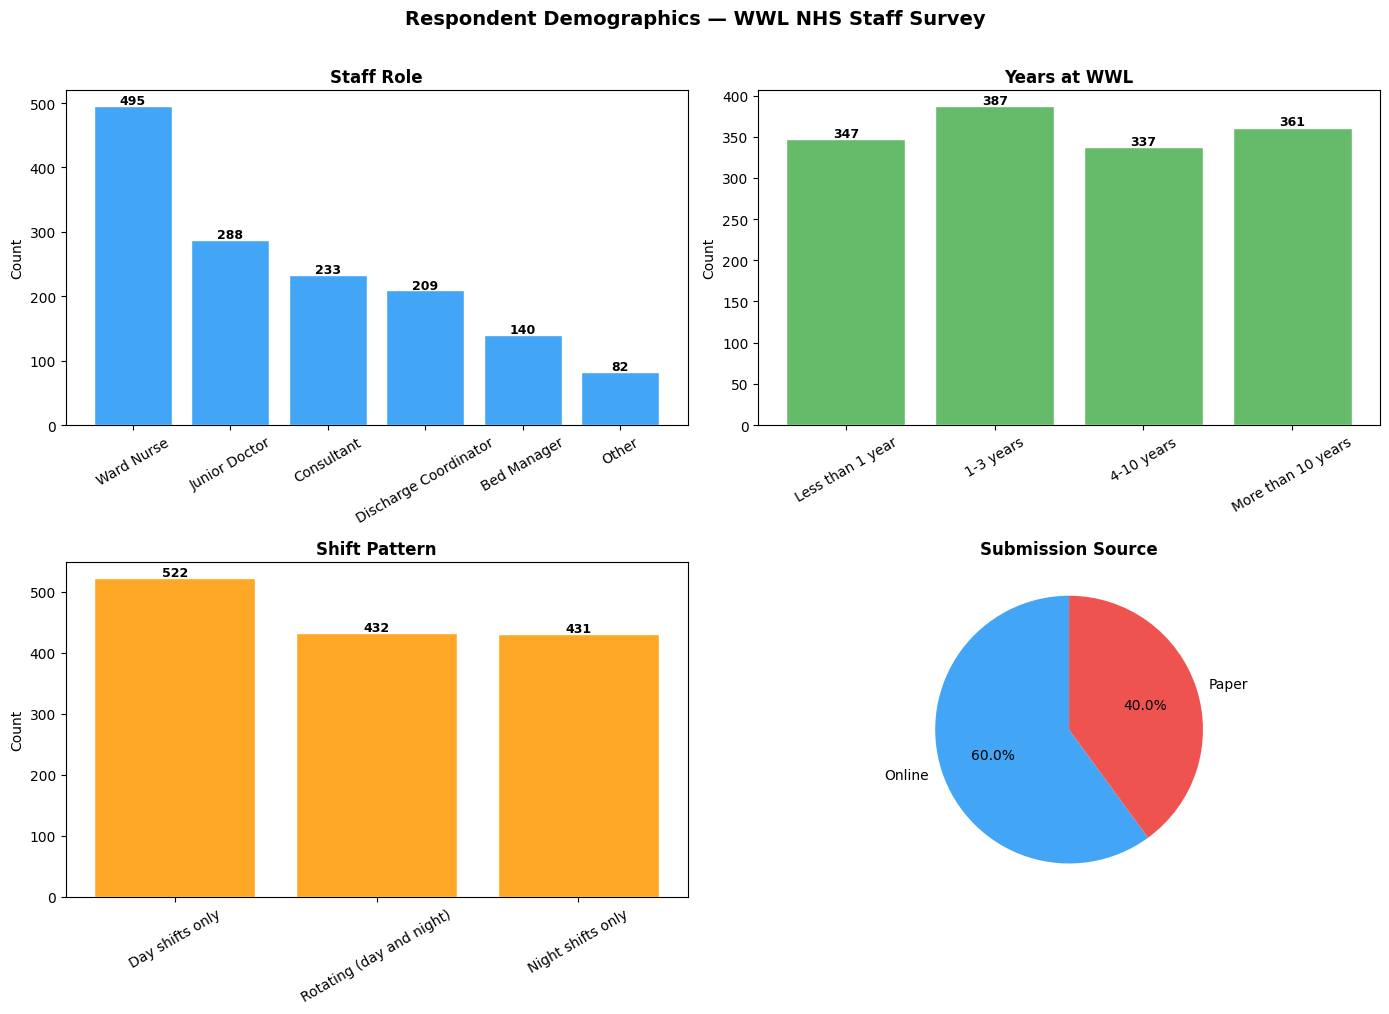

✅ Chart saved as chart_demographics.png


In [9]:
# ── Role breakdown ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Respondent Demographics — WWL NHS Staff Survey',
             fontsize=14, fontweight='bold', y=1.01)

# Plot 1 — Role
role_counts = df['A1_role_clean'].value_counts().dropna()
axes[0,0].bar(role_counts.index, role_counts.values,
              color='#42A5F5', edgecolor='white')
axes[0,0].set_title('Staff Role', fontweight='bold')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(role_counts.values):
    axes[0,0].text(i, v+3, str(v), ha='center', fontsize=9, fontweight='bold')

# Plot 2 — Years at WWL
years_counts = df['A4_years_at_WWL_clean'].value_counts().dropna()
order = ['Less than 1 year','1-3 years','4-10 years','More than 10 years']
years_ordered = years_counts.reindex(order).dropna()
axes[0,1].bar(years_ordered.index, years_ordered.values,
              color='#66BB6A', edgecolor='white')
axes[0,1].set_title('Years at WWL', fontweight='bold')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=30)
for i, v in enumerate(years_ordered.values):
    axes[0,1].text(i, v+3, str(v), ha='center', fontsize=9, fontweight='bold')

# Plot 3 — Shift Pattern
shift_counts = df['A3_shift_pattern_clean'].value_counts().dropna()
axes[1,0].bar(shift_counts.index, shift_counts.values,
              color='#FFA726', edgecolor='white')
axes[1,0].set_title('Shift Pattern', fontweight='bold')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=30)
for i, v in enumerate(shift_counts.values):
    axes[1,0].text(i, v+3, str(v), ha='center', fontsize=9, fontweight='bold')

# Plot 4 — Submission Source
source_counts = df['submission_source_clean'].value_counts().dropna()
axes[1,1].pie(source_counts.values,
              labels=source_counts.index,
              autopct='%1.1f%%',
              colors=['#42A5F5','#EF5350'],
              startangle=90)
axes[1,1].set_title('Submission Source', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart_demographics.png")

=== H SECTION: PERCEIVED USEFULNESS (ALL RESPONDENTS) ===
        H1_clean  H2_clean  H3_clean
count     914.00    942.00    914.00
mean        3.10      3.03      3.03
std         1.41      1.42      1.41
min         1.00      1.00      1.00
25%         2.00      2.00      2.00
50%         3.00      3.00      3.00
75%         4.00      4.00      4.00
max         5.00      5.00      5.00
median      3.00      3.00      3.00

Overall mean across H1-H3: 3.05 / 5


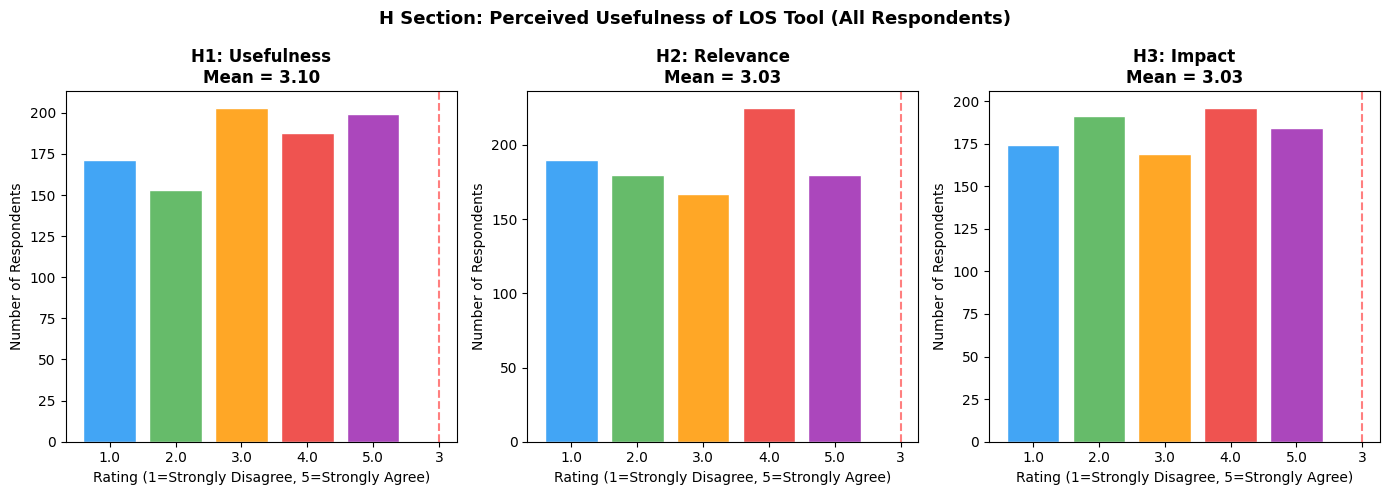

✅ Chart saved as chart_h_section.png


In [11]:
h_cols = ['H1_clean','H2_clean','H3_clean']

# ── Stats ────────────────────────────────────────────────────────────
print("=== H SECTION: PERCEIVED USEFULNESS (ALL RESPONDENTS) ===")
h_stats = df[h_cols].describe().round(2)
h_stats.loc['median'] = df[h_cols].median()
print(h_stats)
print(f"\nOverall mean across H1-H3: {df[h_cols].mean().mean():.2f} / 5")

# ── Grouped bar chart showing response distribution ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('H Section: Perceived Usefulness of LOS Tool (All Respondents)',
             fontsize=13, fontweight='bold')

h_labels = ['H1: Usefulness', 'H2: Relevance', 'H3: Impact']
colors    = ['#42A5F5','#66BB6A','#FFA726','#EF5350','#AB47BC']

for i, (col, label) in enumerate(zip(h_cols, h_labels)):
    counts = df[col].value_counts().sort_index()
    axes[i].bar(counts.index.astype(str), counts.values,
                color=colors[:len(counts)], edgecolor='white')
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_xlabel('Rating (1=Strongly Disagree, 5=Strongly Agree)')
    axes[i].set_ylabel('Number of Respondents')
    axes[i].axvline(x=str(int(df[col].mean().round())),
                    color='red', linestyle='--', alpha=0.5, label='Mean')

    # Add mean line annotation
    mean_val = df[col].mean()
    axes[i].set_title(f'{label}\nMean = {mean_val:.2f}', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_h_section.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart_h_section.png")

=== MEAN PERCEIVED USEFULNESS BY ROLE ===
                       H1: Usefulness  H2: Relevance  H3: Impact
A1_role_clean                                                   
Bed Manager                      2.99           2.97        3.01
Consultant                       3.17           2.87        2.92
Discharge Coordinator            3.20           2.92        3.24
Junior Doctor                    3.04           3.20        3.04
Other                            3.18           3.06        3.17
Ward Nurse                       3.12           3.07        2.91


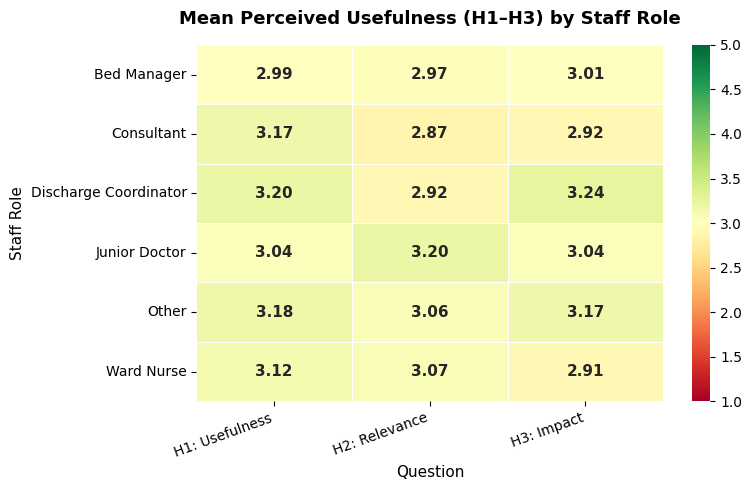

✅ Chart saved as chart_heatmap_role.png


In [13]:
# ── Mean H scores by staff role ──────────────────────────────────────
role_h = df.groupby('A1_role_clean')[h_cols].mean().round(2)
role_h.columns = ['H1: Usefulness','H2: Relevance','H3: Impact']

print("=== MEAN PERCEIVED USEFULNESS BY ROLE ===")
print(role_h)

# ── Heatmap ──────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.heatmap(
    role_h,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=1, vmax=5,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('Mean Perceived Usefulness (H1–H3) by Staff Role',
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Staff Role', fontsize=11)
plt.xlabel('Question', fontsize=11)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('chart_heatmap_role.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as chart_heatmap_role.png")

In [15]:
from scipy.stats import kruskal

print("=== KRUSKAL-WALLIS TEST: DO SCORES DIFFER SIGNIFICANTLY BY ROLE? ===")
print("(Tests whether perceived usefulness scores vary across staff roles)\n")

roles  = df['A1_role_clean'].dropna().unique()
h_labels_full = {
    'H1_clean': 'H1 Usefulness',
    'H2_clean': 'H2 Relevance',
    'H3_clean': 'H3 Impact'
}

results = []
for col, label in h_labels_full.items():
    groups = [
        df[df['A1_role_clean'] == role][col].dropna()
        for role in roles
    ]
    groups = [g for g in groups if len(g) >= 5]
    stat, p = kruskal(*groups)
    significance = '✅ SIGNIFICANT (p < 0.05)' if p < 0.05 else '❌ Not significant'
    results.append({
        'Question': label,
        'H-statistic': round(stat, 3),
        'p-value': round(p, 4),
        'Result': significance
    })
    print(f"{label}: H={stat:.3f}, p={p:.4f} → {significance}")

print("\n── Interpretation ──────────────────────────────────────────────")
print("A significant result means score differences between roles are")
print("unlikely to be due to chance and are a real finding.")

=== KRUSKAL-WALLIS TEST: DO SCORES DIFFER SIGNIFICANTLY BY ROLE? ===
(Tests whether perceived usefulness scores vary across staff roles)

H1 Usefulness: H=2.234, p=0.8159 → ❌ Not significant
H2 Relevance: H=5.746, p=0.3317 → ❌ Not significant
H3 Impact: H=5.911, p=0.3150 → ❌ Not significant

── Interpretation ──────────────────────────────────────────────
A significant result means score differences between roles are
unlikely to be due to chance and are a real finding.


In [17]:
# Test that NLP libraries installed correctly
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from transformers import pipeline
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from wordcloud import WordCloud

print("✅ All NLP libraries loaded successfully")
print("✅ Ready for qualitative analysis")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rumsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\rumsh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


✅ All NLP libraries loaded successfully
✅ Ready for qualitative analysis


In [19]:
import re
from nltk.corpus import stopwords

# ── Define qualitative columns ───────────────────────────────────────
text_cols = {
    'K2_open_biggest_barriers':   'Barriers',
    'L1_open_suggestions':        'Suggestions',
    'C9_open_features_wanted':    'Features Wanted',
    'E3_open_what_would_change':  'What Would Change Mind'
}

# ── Junk responses to remove ─────────────────────────────────────────
junk = ['n/a','na','nothing','none','no','yes','-','.','',
        'not applicable','unsure','ok','fine','unknown']

# ── Function to clean each text column ──────────────────────────────
def prep_text(series, label):
    cleaned = (
        series
        .dropna()
        .astype(str)
        .str.strip()
        .str.lower()
    )
    cleaned = cleaned[~cleaned.isin(junk)]
    cleaned = cleaned[cleaned.str.len() > 5]
    return pd.DataFrame({
        'text':   cleaned.values,
        'source': label
    })

# ── Combine all columns into one dataframe ───────────────────────────
text_dfs = [
    prep_text(df[col], label)
    for col, label in text_cols.items()
]
text_df = pd.concat(text_dfs, ignore_index=True)

# ── Summary ──────────────────────────────────────────────────────────
print("=== USABLE FREE TEXT RESPONSES ===")
for source, group in text_df.groupby('source'):
    print(f"{source:30s}: {len(group):>4} responses")

print(f"\nTotal usable responses: {len(text_df)}")
print("\n── Sample responses from Barriers column ───────────────────")
barriers_sample = text_df[text_df['source'] == 'Barriers']['text'].head(5)
for i, t in enumerate(barriers_sample, 1):
    print(f"{i}. {t[:120]}")

=== USABLE FREE TEXT RESPONSES ===
Barriers                      :  810 responses
Features Wanted               :  110 responses
Suggestions                   :  903 responses
What Would Change Mind        :  287 responses

Total usable responses: 2110

── Sample responses from Barriers column ───────────────────
1. the predctions are not accurate enough to be clinically useful in my experience. we had several patients flagged as low 
2. our ward doesnt use it. the consultant hasnt mentioned it and without their buy in nobody else will adopt it either. thi
3. the main issue is that the tool sits on a completely separate system and nobody has time to log in to check it during a 
4. the dashboard is too complicated. needs to be simplified for busy ward staff who don't have time to interpret complex gr
5. there is no feedback loop - i never find out if the prediction was correct so i can't build confidence in the tool


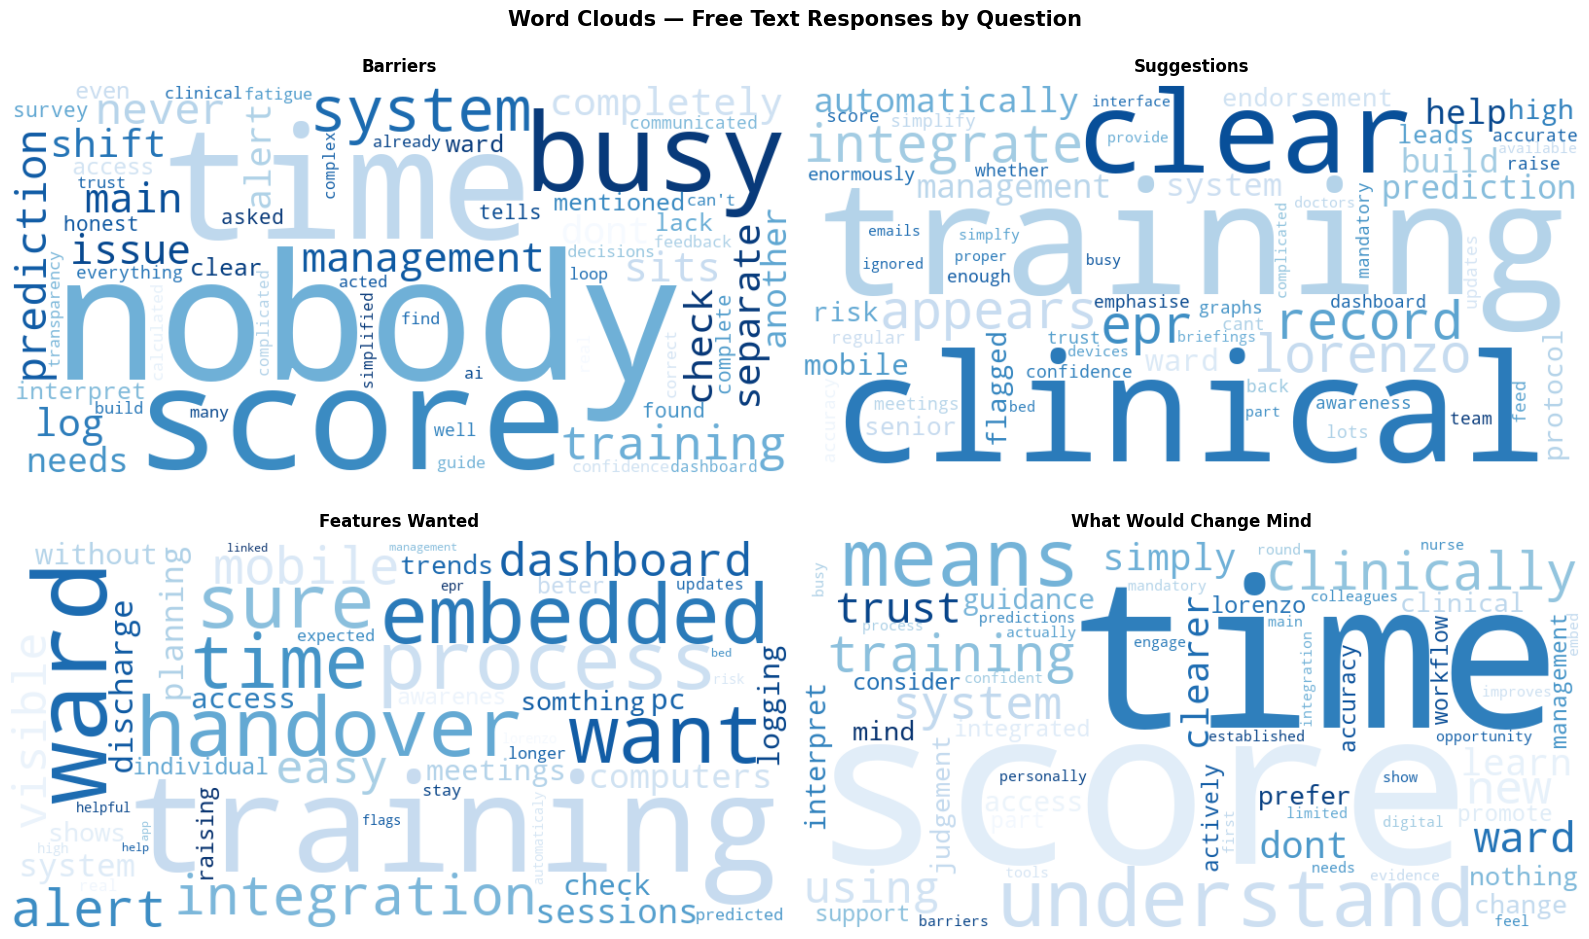

✅ Word clouds saved as chart_wordclouds.png


In [21]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))
stop_words.update([
    'n/a','would','need','also','use','used','tool',
    'one','think','really','make','get','know','like',
    'staff','patient','patients','los','wwl'
])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Word Clouds — Free Text Responses by Question',
             fontsize=15, fontweight='bold')

sources = list(text_cols.values())
axes_flat = axes.flatten()

for i, source in enumerate(sources):
    text_blob = ' '.join(
        text_df[text_df['source'] == source]['text'].tolist()
    )

    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        stopwords=stop_words,
        colormap='Blues',
        max_words=60,
        collocations=False
    ).generate(text_blob)

    axes_flat[i].imshow(wc, interpolation='bilinear')
    axes_flat[i].axis('off')
    axes_flat[i].set_title(source, fontsize=12,
                           fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('chart_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word clouds saved as chart_wordclouds.png")

In [23]:
from transformers import pipeline

print("Loading sentiment model — this may take a few minutes first time...")
print("You will see a progress bar below.\n")

# ── Load model ───────────────────────────────────────────────────────
sentiment_pipe = pipeline(
    'sentiment-analysis',
    model='cardiffnlp/twitter-roberta-base-sentiment-latest',
    truncation=True,
    max_length=512
)
print("✅ Sentiment model loaded\n")

# ── Run sentiment in batches ─────────────────────────────────────────
batch_size = 32
results    = []

for i in range(0, len(text_df), batch_size):
    batch        = text_df['text'].iloc[i:i+batch_size].tolist()
    batch_result = sentiment_pipe(batch)
    results.extend(batch_result)

    if i % 100 == 0:
        print(f"  Processed {min(i+batch_size, len(text_df))}"
              f"/{len(text_df)} responses...")

# ── Add results to dataframe ─────────────────────────────────────────
text_df['sentiment_label'] = [r['label'] for r in results]
text_df['sentiment_score']  = [round(r['score'], 3) for r in results]

# ── Summary table ────────────────────────────────────────────────────
print("\n=== SENTIMENT DISTRIBUTION ACROSS ALL RESPONSES ===")
print(text_df['sentiment_label'].value_counts())

print("\n=== SENTIMENT BY QUESTION ===")
sentiment_by_source = (
    text_df.groupby(['source','sentiment_label'])
    .size()
    .unstack(fill_value=0)
)
print(sentiment_by_source)

Loading sentiment model — this may take a few minutes first time...
You will see a progress bar below.



config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✅ Sentiment model loaded

  Processed 32/2110 responses...
  Processed 832/2110 responses...
  Processed 1632/2110 responses...

=== SENTIMENT DISTRIBUTION ACROSS ALL RESPONSES ===
sentiment_label
neutral     1199
negative     765
positive     146
Name: count, dtype: int64

=== SENTIMENT BY QUESTION ===
sentiment_label         negative  neutral  positive
source                                             
Barriers                     637      173         0
Features Wanted                0       98        12
Suggestions                   52      733       118
What Would Change Mind        76      195        16


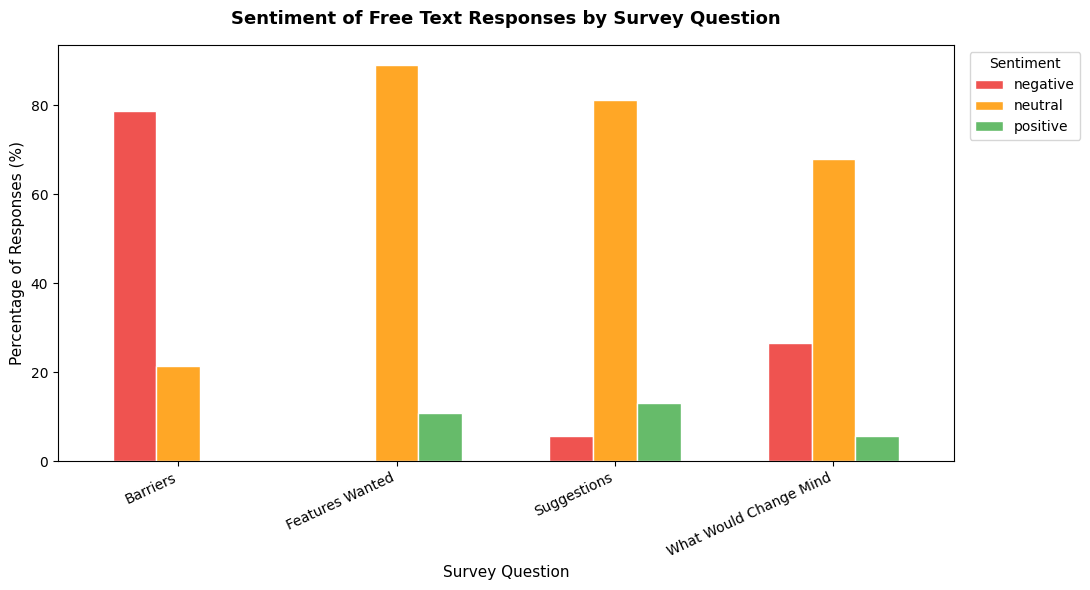

✅ Sentiment chart saved as chart_sentiment.png


In [25]:
# ── Stacked bar chart of sentiment by question ───────────────────────
sentiment_pct = sentiment_by_source.div(
    sentiment_by_source.sum(axis=1), axis=0
) * 100

# Define colours — map whatever labels the model returns
color_map = {
    'positive': '#66BB6A',
    'neutral':  '#FFA726',
    'negative': '#EF5350',
    'Positive': '#66BB6A',
    'Neutral':  '#FFA726',
    'Negative': '#EF5350',
}
bar_colors = [color_map.get(col, '#9E9E9E')
              for col in sentiment_pct.columns]

ax = sentiment_pct.plot(
    kind='bar',
    figsize=(11, 6),
    color=bar_colors,
    edgecolor='white',
    width=0.6
)

plt.title('Sentiment of Free Text Responses by Survey Question',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Survey Question', fontsize=11)
plt.ylabel('Percentage of Responses (%)', fontsize=11)
plt.xticks(rotation=25, ha='right')
plt.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('chart_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sentiment chart saved as chart_sentiment.png")

In [27]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

print("Loading sentence transformer model...")
print("This may take a few minutes first time.\n")

# ── Load embedding model ─────────────────────────────────────────────
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Embedding model loaded\n")

# ── Get barriers text ────────────────────────────────────────────────
barriers_text = text_df[
    text_df['source'] == 'Barriers'
]['text'].tolist()

print(f"Running BERTopic on {len(barriers_text)} barrier responses...")
print("Please wait — this takes 10-20 minutes on Windows...\n")

# ── Fit BERTopic ─────────────────────────────────────────────────────
topic_model = BERTopic(
    embedding_model=embedding_model,
    nr_topics=8,
    min_topic_size=10,
    verbose=True,
    calculate_probabilities=True
)

topics, probs = topic_model.fit_transform(barriers_text)

print("\n✅ BERTopic complete!")
print(f"Topics discovered: {len(set(topics)) - 1}")  # -1 excludes outlier topic

Loading sentence transformer model...
This may take a few minutes first time.



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

✅ Embedding model loaded

Running BERTopic on 810 barrier responses...
Please wait — this takes 10-20 minutes on Windows...



2026-05-25 12:42:44,842 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/26 [00:00<?, ?it/s]

2026-05-25 12:42:57,397 - BERTopic - Embedding - Completed ✓
2026-05-25 12:42:57,401 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-25 12:43:24,779 - BERTopic - Dimensionality - Completed ✓
2026-05-25 12:43:24,781 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-25 12:43:24,939 - BERTopic - Cluster - Completed ✓
2026-05-25 12:43:24,940 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-25 12:43:25,013 - BERTopic - Representation - Completed ✓
2026-05-25 12:43:25,014 - BERTopic - Topic reduction - Reducing number of topics
2026-05-25 12:43:25,048 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-25 12:43:25,090 - BERTopic - Representation - Completed ✓
2026-05-25 12:43:25,098 - BERTopic - Topic reduction - Reduced number of topics from 18 to 8



✅ BERTopic complete!
Topics discovered: 7


In [29]:
# ── Get topic info ───────────────────────────────────────────────────
topic_info = topic_model.get_topic_info()

print("=== DISCOVERED TOPICS IN BARRIERS RESPONSES ===\n")
print(f"{'Topic':<8} {'Count':<8} {'Top Keywords'}")
print("-" * 70)

for _, row in topic_info.iterrows():
    if row['Topic'] == -1:
        continue   # skip outlier topic
    topic_id = row['Topic']
    count    = row['Count']
    words    = topic_model.get_topic(topic_id)
    keywords = ', '.join([w[0] for w in words[:6]])
    print(f"Topic {topic_id:<4} {count:<8} {keywords}")

print("\n── Outlier responses (Topic -1) ────────────────────────────")
outlier_count = topic_info[topic_info['Topic'] == -1]['Count'].values[0]
print(f"Responses not assigned to any topic: {outlier_count}")
print("(This is normal — not every response fits neatly into a theme)")

=== DISCOVERED TOPICS IN BARRIERS RESPONSES ===

Topic    Count    Top Keywords
----------------------------------------------------------------------
Topic 0    306      to, it, and, this, tool, that
Topic 1    132      prediction, never, the, no, training, build
Topic 2    91       had, guide, decisions, ai, transparency, trust
Topic 3    79       training, no, team, support, provided, awareness
Topic 4    74       know, access, even, dont, information, protocol
Topic 5    51       alerts, already, real, many, won, fatigue
Topic 6    39       we, it, because, consistently, lorenzo, open
Topic 7    38       what, understand, should, means, or, with

── Outlier responses (Topic -1) ────────────────────────────


IndexError: index 0 is out of bounds for axis 0 with size 0

In [31]:
topic_info = topic_model.get_topic_info()

print("=== DISCOVERED TOPICS IN BARRIERS RESPONSES ===\n")
print(f"{'Topic':<8} {'Count':<8} {'Top Keywords'}")
print("-" * 70)

for _, row in topic_info.iterrows():
    if row['Topic'] == -1:
        continue
    topic_id = row['Topic']
    count    = row['Count']
    words    = topic_model.get_topic(topic_id)
    keywords = ', '.join([w[0] for w in words[:6]])
    print(f"Topic {topic_id:<4} {count:<8} {keywords}")

print("\n── Outlier responses (Topic -1) ────────────────────────────")

# Fixed outlier count
outlier_rows = topic_info[topic_info['Topic'] == -1]
if len(outlier_rows) > 0:
    outlier_count = outlier_rows['Count'].values[0]
    print(f"Responses not assigned to any topic: {outlier_count}")
else:
    print("No outlier responses — all responses assigned to a topic")

print("(This is normal — not every response fits neatly into a theme)")

=== DISCOVERED TOPICS IN BARRIERS RESPONSES ===

Topic    Count    Top Keywords
----------------------------------------------------------------------
Topic 0    306      to, it, and, this, tool, that
Topic 1    132      prediction, never, the, no, training, build
Topic 2    91       had, guide, decisions, ai, transparency, trust
Topic 3    79       training, no, team, support, provided, awareness
Topic 4    74       know, access, even, dont, information, protocol
Topic 5    51       alerts, already, real, many, won, fatigue
Topic 6    39       we, it, because, consistently, lorenzo, open
Topic 7    38       what, understand, should, means, or, with

── Outlier responses (Topic -1) ────────────────────────────
No outlier responses — all responses assigned to a topic
(This is normal — not every response fits neatly into a theme)


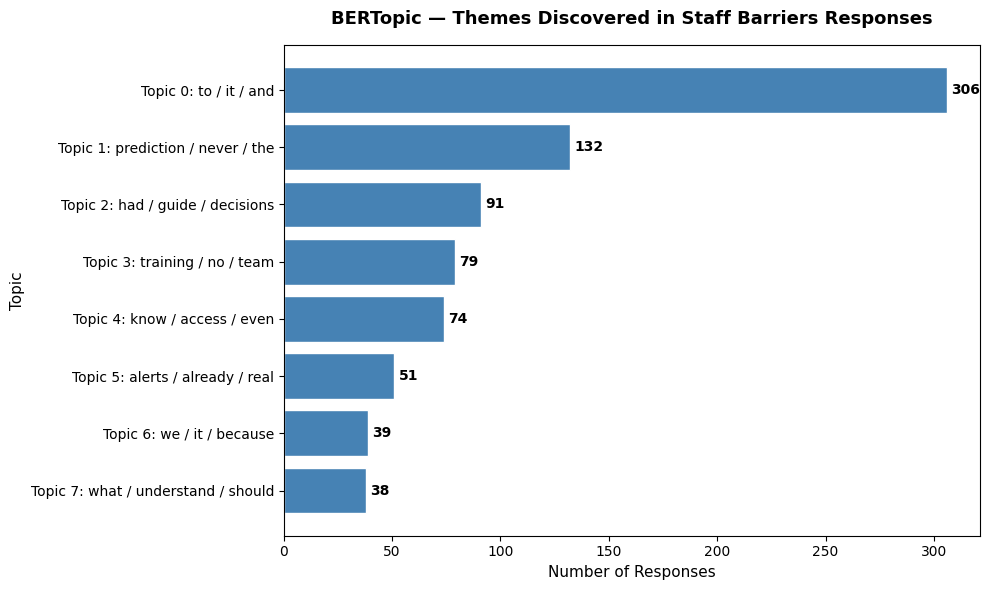

✅ BERTopic chart saved as chart_bertopic_barriers.png


In [33]:
# ── Bar chart of topic sizes ─────────────────────────────────────────
topic_sizes = topic_info[topic_info['Topic'] != -1].copy()
topic_sizes = topic_sizes.sort_values('Count', ascending=True)

# Create readable topic labels from top keywords
topic_labels = {}
for _, row in topic_sizes.iterrows():
    tid   = row['Topic']
    words = topic_model.get_topic(tid)
    label = ' / '.join([w[0] for w in words[:3]])
    topic_labels[tid] = f"Topic {tid}: {label}"

labels = [topic_labels[tid] for tid in topic_sizes['Topic']]
counts = topic_sizes['Count'].tolist()

plt.figure(figsize=(10, 6))
bars = plt.barh(labels, counts, color='steelblue', edgecolor='white')

# Add count labels
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
        str(count), va='center', fontsize=10, fontweight='bold'
    )

plt.title('BERTopic — Themes Discovered in Staff Barriers Responses',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Responses', fontsize=11)
plt.ylabel('Topic', fontsize=11)
plt.tight_layout()
plt.savefig('chart_bertopic_barriers.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ BERTopic chart saved as chart_bertopic_barriers.png")

In [35]:
from transformers import pipeline

print("Loading zero-shot classification model...")
print("This may take a few minutes first time.\n")

# ── Load model ───────────────────────────────────────────────────────
classifier = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    truncation=True
)
print("✅ Zero-shot model loaded\n")

# ── Define NHS-relevant themes ────────────────────────────────────────
candidate_labels = [
    'lack of training',
    'EPR integration needed',
    'distrust of AI predictions',
    'time constraints',
    'lack of management support',
    'technical access issues',
    'alert fatigue',
    'unclear workflow or process',
]

# ── Run on all barriers responses ────────────────────────────────────
barriers_df = text_df[text_df['source'] == 'Barriers'].copy()
print(f"Classifying {len(barriers_df)} barriers responses...")
print("This takes 20-30 minutes on Windows. Please wait...\n")

theme_results = []

for i, text in enumerate(barriers_df['text'].tolist()):
    result    = classifier(text, candidate_labels, multi_label=False)
    top_theme = result['labels'][0]
    top_score = round(result['scores'][0], 3)
    theme_results.append({
        'text':      text,
        'top_theme': top_theme,
        'score':     top_score
    })

    if i % 50 == 0:
        print(f"  Classified {i}/{len(barriers_df)} responses...")

themes_df = pd.DataFrame(theme_results)

print(f"\n✅ Classification complete!")
print("\n=== THEME DISTRIBUTION IN BARRIERS ===")
theme_counts = themes_df['top_theme'].value_counts()
print(theme_counts)

Loading zero-shot classification model...
This may take a few minutes first time.



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Zero-shot model loaded

Classifying 810 barriers responses...
This takes 20-30 minutes on Windows. Please wait...

  Classified 0/810 responses...
  Classified 50/810 responses...
  Classified 100/810 responses...
  Classified 150/810 responses...
  Classified 200/810 responses...
  Classified 250/810 responses...
  Classified 300/810 responses...
  Classified 350/810 responses...
  Classified 400/810 responses...
  Classified 450/810 responses...
  Classified 500/810 responses...
  Classified 550/810 responses...
  Classified 600/810 responses...
  Classified 650/810 responses...
  Classified 700/810 responses...
  Classified 750/810 responses...
  Classified 800/810 responses...

✅ Classification complete!

=== THEME DISTRIBUTION IN BARRIERS ===
top_theme
unclear workflow or process    291
time constraints               207
lack of training               139
lack of management support     122
alert fatigue                   51
Name: count, dtype: int64


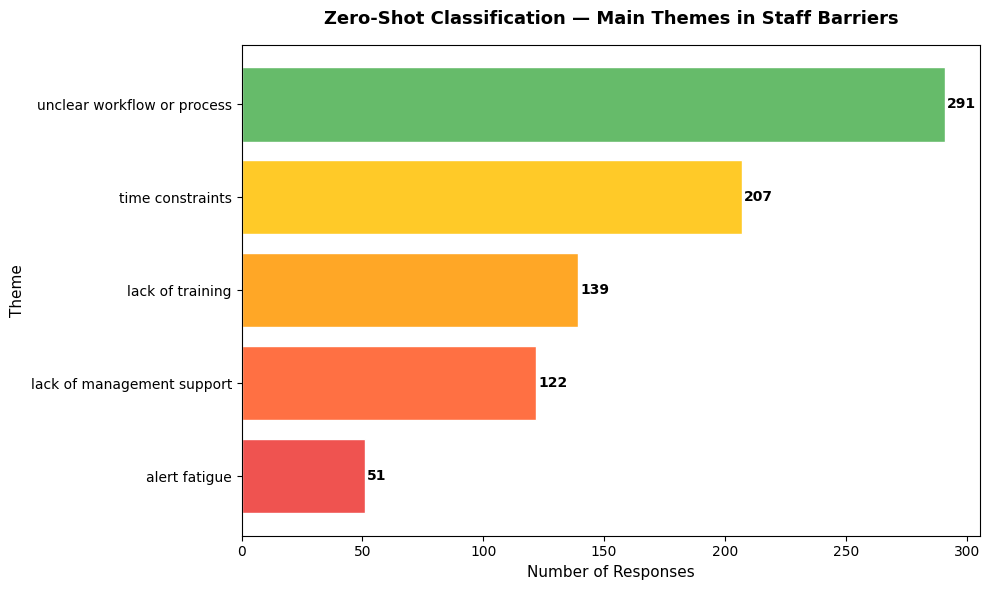

✅ Zero-shot chart saved as chart_zeroshot_themes.png


In [37]:
# ── Horizontal bar chart ─────────────────────────────────────────────
plt.figure(figsize=(10, 6))

colors = [
    '#EF5350','#FF7043','#FFA726','#FFCA28',
    '#66BB6A','#26C6DA','#42A5F5','#AB47BC'
]

bars = plt.barh(
    theme_counts.index[::-1],
    theme_counts.values[::-1],
    color=colors[:len(theme_counts)],
    edgecolor='white'
)

# Add count labels
for bar, count in zip(bars, theme_counts.values[::-1]):
    plt.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        str(count),
        va='center', fontsize=10, fontweight='bold'
    )

plt.title('Zero-Shot Classification — Main Themes in Staff Barriers',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Number of Responses', fontsize=11)
plt.ylabel('Theme', fontsize=11)
plt.tight_layout()
plt.savefig('chart_zeroshot_themes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Zero-shot chart saved as chart_zeroshot_themes.png")

In [39]:
# ── Combined summary of all analysis ─────────────────────────────────
print("=" * 60)
print("   FULL ANALYSIS SUMMARY — WWL LOS TOOL EVALUATION")
print("=" * 60)

print(f"\n📊 DATASET")
print(f"   Total respondents:        {len(df)}")
print(f"   Usable text responses:    {len(text_df)}")

print(f"\n👥 AWARENESS & ADOPTION")
for label in ['Not Aware','Aware Never Used',
              'Used Occasionally','Used Regularly']:
    n   = df['B1_awareness_clean'].eq(label).sum()
    pct = n / len(df) * 100
    print(f"   {label:<25} {n:>4} ({pct:.1f}%)")

print(f"\n📈 LIKERT SCORES (Mean / 5)")
print(f"   H Section — Perceived Usefulness")
for col in ['H1_clean','H2_clean','H3_clean']:
    mean = df[col].mean()
    print(f"   {col:<15} {mean:.2f}")

print(f"\n💬 SENTIMENT ANALYSIS")
for label in ['negative','neutral','positive']:
    n   = text_df['sentiment_label'].eq(label).sum()
    pct = n / len(text_df) * 100
    print(f"   {label:<12} {n:>4} ({pct:.1f}%)")

print(f"\n🔍 BARRIERS SENTIMENT")
b = text_df[text_df['source']=='Barriers']['sentiment_label']
for label in ['negative','neutral','positive']:
    n   = b.eq(label).sum()
    pct = n / len(b) * 100
    print(f"   {label:<12} {n:>4} ({pct:.1f}%)")

print(f"\n🏷️  TOP THEMES IN BARRIERS (Zero-Shot)")
for theme, count in theme_counts.head(5).items():
    pct = count / len(themes_df) * 100
    print(f"   {theme:<35} {count:>3} ({pct:.1f}%)")

print(f"\n📉 STATISTICAL TEST")
print(f"   Kruskal-Wallis — H scores by role: NOT significant")
print(f"   Interpretation: Neutral attitudes are trust-wide,")
print(f"   not specific to any one staff group")

print("\n" + "=" * 60)
print("✅ All analysis complete — charts saved to notebook folder")
print("=" * 60)

   FULL ANALYSIS SUMMARY — WWL LOS TOOL EVALUATION

📊 DATASET
   Total respondents:        1482
   Usable text responses:    2110

👥 AWARENESS & ADOPTION
   Not Aware                  284 (19.2%)
   Aware Never Used           430 (29.0%)
   Used Occasionally          308 (20.8%)
   Used Regularly             269 (18.2%)

📈 LIKERT SCORES (Mean / 5)
   H Section — Perceived Usefulness
   H1_clean        3.10
   H2_clean        3.03
   H3_clean        3.03

💬 SENTIMENT ANALYSIS
   negative      765 (36.3%)
   neutral      1199 (56.8%)
   positive      146 (6.9%)

🔍 BARRIERS SENTIMENT
   negative      637 (78.6%)
   neutral       173 (21.4%)
   positive        0 (0.0%)

🏷️  TOP THEMES IN BARRIERS (Zero-Shot)
   unclear workflow or process         291 (35.9%)
   time constraints                    207 (25.6%)
   lack of training                    139 (17.2%)
   lack of management support          122 (15.1%)
   alert fatigue                        51 (6.3%)

📉 STATISTICAL TEST
   Kruskal-W